# CS156: Pipeline - First Draft

**Do I sound like AI, or have I always been a bad writer?**  

With the amount of AI we use day to day, I am fairly sure that a lot of the content I consume, whether it be the news, social media, or even the PCW that I grade, might be AI-assisted, if not completely AI-generated. This makes me wonder: as a symptom of consuming so much 'slop,' could my own writing also be showing traits commonly attributed to AI-generated text, such as structural uniformity, reduced variance in sentence length, or particular lexical patterns? (Wikipedia, n.d.-a)

This report answers this question by first training a model to classify assignments I wrote pre-Fall 2024, before AI tools had become sufficiently capable and convenient to function as routine academic aids, from later submissions. If the model can reliably distinguish between the two periods, this suggests measurable stylistic differences. I then examine which features drive this separation and analyze whether those differences align with documented stylistic characteristics often associated with AI-generated writing. 

*Note:* I hid some cells for readability before the final export, so some variable names might appear sudden. Please see here for executable version: [GitHub](https://github.com/SuiseiNakagawa/stylistic_drift_analysis/blob/main/first_draft.ipynb)


## The Data

To create the dataset to be used in this pipeline, I retrieved past written assignments from my Minerva email's Google Drive using a Colab notebook ([GitHub](https://colab.research.google.com/drive/1f_YmZ3cR82UPcLH7uNJ9DUu-x7Gllc7c#scrollTo=e160UdxwwBmt)), and manually labelled the documents I wanted to include.

Importantly, since the focus of the models trained here is stylistic drift in *my* writing, I excluded the following assignment categories: 
- **Skill builders from CS111 and CS113:** Mostly math and instructions, not much original prose. Also hand-written, which adds processing complexity.
- **Group assignments:** Written by multiple people, so I limited the dataset to me.
- **Heavily templated assignments:** Workbooks and worksheets with instructions included dilute my own voice. This excluded several FA50/FA51, Deep Dives from CS111/CS113, problem sets from CS114, and some SS110/SS152 assignments formatted as cover sheets.

I did include non-essay documents that reflect my own writing: video scripts and reflection documents from technical interviews.

Based on these criteria, 54 documents qualified. However, 4 were from outside Google Drive (PDFs from OverLeaf or exported jupyter notebooks), so I excluded them to keep data processing consistent. That left 50 documents in the final dataset.

## Loading the Data

The scraped data is stored in a CSV file with UTF-8 encoding, which I chose to preserve punctuation like em-dashes and curly quotes that might carry stylistic signal.

In [ ]:
# Install necessary packages
!pip install pandas numpy scikit-learn matplotlib seaborn scipy textstat nltk spacy wordcloud
!python -m spacy download en_core_web_sm




[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.8 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy

# Sklearn imports
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Stylometric analysis
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/suiseinakagawa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Loading dataset

df = pd.read_csv("gdrive_scraped_data.csv", encoding='utf-8') 


## Pre-processing and EDA

While I am most interested in stylistic drift, I first train a baseline classifier to see whether there is any meaningful difference between my pre-AI (pre-Fall 2024) and post-AI (Fall 2024 and later) writing.

This section describes the exact cleaning steps used in the code and the assumptions behind them.

### Data Cleaning to Prevent Leakage and Labeling

To ensure the classifier learns stylistic patterns rather than metadata, I wanted to train it on cleaned data where elements or sections that may cause leakage are removed. In order to compare model performance across data with different levels of cleaning to verify the model is truly learning from the main text, I created a fixed cleaning pipeline: `remove_cover_sheet` -> `remove_toc` -> `extract_body_only` -> `remove_hc_tags`.

- `text_raw`: Original text with all content. This is pulled directly from the source csv file. 
- `text_clean`: Fully cleaned. This removes the cover sheet, TOC, References, Appendices, and HC/LO tags, which can cause leakage from course/topic/time. I also removed AI Statements because the wording, tool names, and format may shift over time or by course. This is justified as the goal is to capture main-body prose, not these sections, that are less stylistic and more structural. 

I still use an intermediate `no_cover` step inside the pipeline (cover sheet + TOC removed), because the heuristics build on each other, but I decided not to keep it as a permanent column in the final dataframe.

In addition to cleaning, I added the following metadata columns: 
- `course_code`: Extracted from the cover sheet using a 2-letter + 2-3 digit regex. 
- `label`: The label for model training. Pre-AI (pre-Fall 2024) work is represented by 0 and post-AI (Fall 2024 or later) work is represented by 1. This labeling scheme reflects the real-world timeline of when AI tools became standard in my academic toolkit.

Importantly, each cleaning step makes some key assumptions about my data, which I verified as I implemented the code: 

- **Cover sheets or headers exist at the start of the document.** The cover sheet is assumed to appear in the first 500-3000 characters and to contain either a Minerva header, a horizontal rule, a large page break, or a course code. This lets the heuristic remove only the top portion.
- **TOCs are near the top and look like lists with page numbers.** The TOC removal checks the first ~20 lines for multiple lines ending in digits or an explicit "Contents" header.
- **End-matter starts at explicit markers.** The body is truncated at the earliest of: References/Bibliography, Appendix/Appendices, Word Count, or AI Statement/AI Use headings, but only if they appear after 100+ characters.
- **HC/LO tags are structured as #tag: blocks.** The cleaning assumes these are metadata blocks that can be removed without losing core prose.

This setup lets me compare model performance on raw text vs. main-body prose to check whether the model is learning writing style rather than metadata.


In [4]:
# Preprocessing functions

VALID_COURSES = ['CP192', 'CS146', 'GL96', 'CS156', 'SS111',
                 'CP191', 'CS166', 'GL95', 'SS152', 'SS156', 
                 'CS113', 'CS114', 'GL94', 'SS110', 
                 'CS110', 'CS111', 'GL93', 'SS112', 
                 'CX51', 'EA51', 'FA51', 'GL92', 'MC51', 
                 'CX50', 'EA50', 'FA50', 'GL91', 'MC50', 'IL199']

def extract_course_code(text):
    """
    Extract course code from cover sheet (e.g., CS110, GL96).
    
    Searches first 500 chars for 2-letter prefix + 2-3 digit number.
    Returns: course_code or None if not found
    """
    pattern = r'\b([A-Z]{2})[\s-]?(\d{2,3})\b'
    matches = re.findall(pattern, text[:500])
    
    if matches:
        prefix, number = matches[0]
        return f"{prefix}{number}"
    
    return None

def remove_cover_sheet(text):
    """
    Remove cover sheet content using layered heuristics.
    
    Strategies (applied in order):
    1) Minerva-specific: Searches for horizontal rules or TOC header in first 3000 chars
    2) Major page break: 6+ consecutive blank lines
    3) Early horizontal rule: 5+ underscores in first 2000 chars
    4) Course code fallback: Skips 2 lines after finding course code
    """
    text = text.replace('\r\n', '\n')

    if 'Minerva University' in text[:500]:
        early_section = text[:3000]
        rule_match = re.search(r'\n\s*_{5,}\s*\n', early_section)
        toc_match = re.search(r'(?i)\n\s*(table of )?contents\s*\n', early_section)
        candidates = []
        if rule_match:
            candidates.append(('rule', rule_match.start(), rule_match.end()))
        if toc_match:
            candidates.append(('toc', toc_match.start(), toc_match.end()))
        if candidates:
            kind, start, end = min(candidates, key=lambda x: x[1])
            return text[start:] if kind == 'toc' else text[end:]

    page_break_pattern = r'(\n\s*){6,}'
    match = re.search(page_break_pattern, text)
    if match:
        return text[match.end():]

    horizontal_rule_pattern = r'\n\s*_{5,}\s*\n'
    match = re.search(horizontal_rule_pattern, text[:2000])
    if match:
        return text[match.end():]

    course_code_pattern = r'\b([A-Z]{2})[\s-]?(\d{2,3})\b'
    match = re.search(course_code_pattern, text[:500])
    if match:
        pos = match.end()
        for _ in range(2):
            next_newline = text.find('\n', pos)
            if next_newline == -1:
                break
            pos = next_newline + 1
        return text[pos:]

    return text

def remove_hc_tags(text):
    """
    Remove HC tags (#tag: explanation) and standalone horizontal rules.
    
    Removes:
    - HC tag blocks: #tag: explanation (continues until blank line)
    - Horizontal rules: Lines with 5+ underscores
    """
    text = re.sub(r'\#[A-Za-z0-9\-]+:[^\n]*(?:\n(?!\n)[^\n]*)*', '', text)
    text = re.sub(r'^\s*_{5,}\s*$', '', text, flags=re.MULTILINE)
    return text

def remove_toc(text):
    """
    Remove table of contents blocks using two strategies.
    
    Strategy 1 - Explicit header: Matches "Table of Contents" or "Contents" header.
                 Ends at double newline or horizontal rule.
    Strategy 2 - Page number heuristic: Detects 3+ lines ending with digits in first 20 lines.
                 Removes up to first double blank line, or first blank line as fallback.
    """
    text = text.replace('\r\n', '\n')

    toc_pattern = r'(?i)(table of )?contents\s*\n'
    match = re.search(toc_pattern, text)
    if match:
        toc_start = match.start()
        remaining = text[match.end():]
        end_match = re.search(r'\n\s*\n|\n\s*_{5,}\s*\n', remaining)
        if end_match:
            return text[:toc_start] + remaining[end_match.end():].lstrip()
        return text[:toc_start]

    lines = text.split('\n')
    sample = lines[:20]
    toc_like = [ln for ln in sample if re.search(r'\s+\d+\s*$', ln)]
    if len(toc_like) >= 3:
        for i in range(len(sample) - 1):
            if sample[i].strip() == '' and sample[i + 1].strip() == '':
                return '\n'.join(lines[i + 1:]).lstrip()
        for i in range(len(sample)):
            if sample[i].strip() == '':
                return '\n'.join(lines[i + 1:]).lstrip()

    return text

def extract_body_only(text):
    """
    Extract main body text by cutting at the earliest end-of-body marker.
    
    Detects: References, Bibliography, Appendix, Appendices, Word Count, AI Statement variants.
    Protection: Only cuts if marker appears after 100+ chars (prevents removing entire document).
    """
    text = text.replace('\r\n', '\n')
    
    end_markers = [
        r'(?i)^(references|bibliography)',
        r'(?i)^(appendix|appendices)',
        r'(?i)^(word count|ai statement|ai use|statement on ai)',
    ]
    
    earliest_match = None
    earliest_pos = len(text)
    
    for pattern in end_markers:
        match = re.search(pattern, text, re.MULTILINE)
        if match and match.start() > 100 and match.start() < earliest_pos:
            earliest_pos = match.start()
            earliest_match = match
    
    if earliest_match:
        return text[:earliest_match.start()].strip()
    
    return text.strip()


def preprocess_dataframe(df):
    """
    Apply all preprocessing steps to create cleaned text columns.
    
    Columns created:
    - text_raw: Original text (baseline)
    - text_clean: Body text only (no coversheet, TOC, references, appendix, AI statements, HC tags)
    - course_code: Extracted course code
    - label: 0 = pre-AI courses, 1 = post-AI courses
    """
    df_processed = df.copy()
    df_processed['course_code'] = df_processed['text_raw'].apply(extract_course_code)
    df_processed['no_cover'] = df_processed['text_raw'].apply(remove_cover_sheet).apply(remove_toc)
    df_processed['text_clean'] = df_processed['no_cover'].apply(extract_body_only).apply(remove_hc_tags)
    PRE_AI_COURSES = ['CX51', 'EA51', 'FA51', 'GL92', 'MC51', 
                      'CX50', 'EA50', 'FA50', 'GL91', 'MC50', 'IL199']
    df_processed['label'] = df_processed['course_code'].apply(
        lambda x: 0 if x in PRE_AI_COURSES else 1
    )
    
    return df_processed

# Apply preprocessing and keep relevant columns
df_processed = preprocess_dataframe(df)
df_processed = df_processed[['name', 'course_code', 'label', 'text_raw', 'text_clean']]

print("Preprocessing complete.")
print(f"Total documents: {len(df_processed)}")

# Display summary table with truncated text for readability
display_df = df_processed.head().copy()
text_cols = ['text_raw', 'text_clean']
for col in text_cols:
    display_df[col] = display_df[col].apply(lambda x: (x[:75] + '...') if isinstance(x, str) and len(x) > 75 else x)
display(display_df[['course_code', 'name', 'label'] + text_cols])

Preprocessing complete.
Total documents: 50


,course_code,name,label,text_raw,text_clean
0,CP192,Reflection on Track Options [final],1,﻿Reflection on Track Options\r\n\r\n\r\n\r\n\r...,Reflection on Track Options\nProcess Documenta...
1,SS111,LBA [final],1,﻿LBA: Analyzing the Bangle Market of Charminar...,LBA: Analyzing the Bangle Market of Charminar\...
2,GL96,Elevation Reflection & Engagement [final],1,﻿Elevation Reflection & Engagement \r\nGL96\r\...,One way I plan to engage meaningfully with Hyd...
3,GL96,Ethnographic Assignment [final],1,﻿Ethnographic Assignment\r\n\r\n\r\n\r\n\r\nMi...,Ethnographic Assignment\nIntroduction\nFor thi...
4,SS156,Final assignment [final],1,﻿Tab 1\r\n\r\n\r\n\r\n\r\n\r\n\r\nComparative ...,Comparative Analysis of Political Systems: Fur...


In [5]:
# # Manual inspection of all documents
# # Commented out to reduce bulk

# pd.set_option('display.max_colwidth', None)

# for idx, row in df_processed.iterrows():
#     print(f"\n{'='*100}")
#     print(f"📄 Document #{idx + 1}: {row['name']}")
#     print(f"   Course: {row['course_code']} | Label: {row['label']} ({'pre-AI' if row['label'] == 0 else 'post-AI'})")
#     print(f"{'='*100}")
        
#     print(f"\n[TEXT_CLEAN - First 100 chars]")
#     print(row['text_clean'][:100] if isinstance(row['text_clean'], str) else row['text_clean'])
#     print(f"\n[TEXT_CLEAN - Last 100 chars]")
#     print(row['text_clean'][-100:] if isinstance(row['text_clean'], str) else row['text_clean'])

### Text Normalization and Tokenization

In addition to separating main text from structural artefacts, I standardize case and whitespace to reduce surface-level variation (e.g., casing and uneven spacing) before tokenization using spaCy. I chose spaCy over a simple regex-based tokenizer because this analysis depends on consistent sentence boundaries and stable token definitions. Naive regex rules tend to break on abbreviations, decimal numbers, ellipses, and formatting irregularities, which would directly distort structural metrics of interest like mean sentence length and variance. 

I disable part-of-speech tagging, dependency parsing, named entity recognition, and lemmatization to keep the pipeline lightweight and deterministic. In particular, lemmatization would collapse inflected word forms and remove variation that may itself be stylistically meaningful.

This step produces three representations per document: a list of tokens (including punctuation), a word list excluding whitespace, and a list of sentence strings. These structured outputs form the basis for feature engineering and exploratory analysis. 

Upon tokenization, I split raw vs. clean text into separate dataframes so the core metadata stays small and I can compare feature sets cleanly without carrying around extra columns. That also makes it easy to swap in either raw or clean inputs for each model.


In [6]:
# Normalization 

def normalize_text(text):
    """Lowercase and collapse whitespace for consistent tokenization."""
    if not isinstance(text, str):
        return text
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Create a normalized column from the raw and cleaned text
df_processed["text_raw_norm"] = df_processed["text_raw"].apply(normalize_text)
df_processed["text_clean_norm"] = df_processed["text_clean"].apply(normalize_text)

print("Normalization complete.")

# Display summary table with truncated text for readability
display_df = df_processed.head().copy()
text_cols = ['name', 'text_raw_norm', 'text_clean_norm']
for col in text_cols:
    display_df[col] = display_df[col].apply(lambda x: (x[:75] + '...') if isinstance(x, str) and len(x) > 75 else x)
display(display_df[['course_code', 'name', 'label'] + text_cols])


Normalization complete.


,course_code,name,label,name,text_raw_norm,text_clean_norm
0,CP192,Reflection on Track Options [final],1,Reflection on Track Options [final],﻿reflection on track options minerva universit...,reflection on track options process documentat...
1,SS111,LBA [final],1,LBA [final],﻿lba: analyzing the bangle market of charminar...,lba: analyzing the bangle market of charminar ...
2,GL96,Elevation Reflection & Engagement [final],1,Elevation Reflection & Engagement [final],﻿elevation reflection & engagement gl96 suisei...,one way i plan to engage meaningfully with hyd...
3,GL96,Ethnographic Assignment [final],1,Ethnographic Assignment [final],﻿ethnographic assignment minerva university gl...,ethnographic assignment introduction for this ...
4,SS156,Final assignment [final],1,Final assignment [final],﻿tab 1 comparative analysis of political syste...,comparative analysis of political systems: fur...


In [7]:
# SpaCy tokenizer

nlp = spacy.load("en_core_web_sm", disable=["ner", "tagger", "parser", "lemmatizer"])
nlp.add_pipe("sentencizer")

def spacy_tokenize(text):
    """
    Tokenize text with spaCy.

    Returns a dict with:
    - tokens: all tokens including punctuation
    - words: tokens excluding spaces
    - sentences: list of sentence strings
    """
    if not isinstance(text, str):
        return {"tokens": [], "words": [], "sentences": []}

    doc = nlp(text)
    tokens = [token.text for token in doc]
    words = [token.text for token in doc if not token.is_space]
    sentences = [sent.text.strip() for sent in doc.sents]

    return {"tokens": tokens, "words": words, "sentences": sentences}

# Keep tokenized outputs separate to avoid bloating the main dataframe
base_cols = ["name", "course_code", "label"]

df_tokens_raw = df_processed[base_cols + ["text_raw_norm"]].copy()
df_tokens_clean = df_processed[base_cols + ["text_clean_norm"]].copy()

df_tokens_raw["token_data"] = df_tokens_raw["text_raw_norm"].apply(spacy_tokenize)
df_tokens_clean["token_data"] = df_tokens_clean["text_clean_norm"].apply(spacy_tokenize)

print("Tokenization complete. Token outputs saved to df_tokens_raw and df_tokens_clean.")

Tokenization complete. Token outputs saved to df_tokens_raw and df_tokens_clean.


### Feature Engineering

To train my models to recognize AI-like writing (Wikipedia, n.d.-b), I decided to engineer the following features commonly used in authorship analysis (Hastewire, 2025-a; Hastewire, 2025-b): 

* Structural
    * Mean sentence length (words per sentence): AI-generated text tends to be comprised of long sentences with complex structure. 
    * Sentence length variability (standard deviation): Not only does AI text tend to be long-winded, it is *consistently* long, with lower variance in sentence length than human-produced writing. 

* Lexical
    * Lexical diversity (unique words / total words): AI (specifically, LLMs) are probabilistic models, and tend to 'regress towards the mean' 

* Punctuation (count per total tokens)
    * Comma rate: Clause density, like sentence length, is more varied in human writing compared to uniformly complex AI prose. 
    * Semicolon rate: Semicolons are frequent in formal published text (books, academic writing) where LLMs extract most of their training signal. 
    * Colon rate: Colons introduce explanations, lists, definitions, and other structured chunks of information, which could be more common in AI training data.  
    * Dash rate: LLMs overuse em-dashes; this is a well-documented AI hallmark. 

* Function words (count per total words): The use of function words is often unconscious and thus a good indicator of personal style, and their use if often consistent across subject matter. Here I chose to encode the relative frequency of the 5 most commonly used function words based on the  Oxford English Corpus (OEC) (Wikipedia, n.d.-b). 
    * the
    * to
    * of
    * and
    * a/an (counted together as a single feature, since they're functionally equivalent)

In [8]:
# Feature Engineering

def compute_features(df_tokens):
    """
    Compute 12 stylometric features from tokenized data.
    
    Features:
    1-2: Mean sentence length (words/sentence), sentence length variability (std dev of sentence lengths)
    3: Lexical diversity (unique words / total words)
    4-7: Punctuation rates per token: comma, semicolon, colon, dash (punctuation count / total tokens)
    8-12: Function word frequencies per word: the, to, of, and, a/an (word count / total words)
    """
    features = []
    
    for idx, row in df_tokens.iterrows():
        token_dict = row["token_data"]
        words = token_dict["words"]
        tokens = token_dict["tokens"]
        sentences = token_dict["sentences"]
        
        feat_dict = {"name": row["name"], "course_code": row["course_code"], "label": row["label"]}
        
        # 1. Mean sentence length
        if sentences:
            sent_lengths = [len(s.split()) for s in sentences]
            feat_dict["mean_sent_len"] = np.mean(sent_lengths)
        else:
            feat_dict["mean_sent_len"] = 0
        
        # 2. Sentence length variability (std dev)
        if len(sentences) > 1:
            feat_dict["sent_len_var"] = np.std(sent_lengths)
        else:
            feat_dict["sent_len_var"] = 0
        
        # 3. Lexical diversity
        total_words = len(words)
        unique_words = len(set(words))
        feat_dict["lex_diversity"] = unique_words / total_words if total_words > 0 else 0
        
        # 4-7. Punctuation rates
        total_tokens = len(tokens)
        feat_dict["comma_rate"] = tokens.count(",") / total_tokens if total_tokens > 0 else 0
        feat_dict["semicolon_rate"] = tokens.count(";") / total_tokens if total_tokens > 0 else 0
        feat_dict["colon_rate"] = tokens.count(":") / total_tokens if total_tokens > 0 else 0
        feat_dict["dash_rate"] = (tokens.count("-") + tokens.count("–") + tokens.count("—")) / total_tokens if total_tokens > 0 else 0
        
        # 8-12. Function word frequencies
        function_words = {"the", "to", "of", "and"}
        words_lower = [w.lower() for w in words]
        for fw in function_words:
            feat_dict[f"freq_{fw}"] = words_lower.count(fw) / total_words if total_words > 0 else 0
        
        # Special handling for a/an (count both as single feature)
        a_an_count = words_lower.count("a") + words_lower.count("an")
        feat_dict["freq_a"] = a_an_count / total_words if total_words > 0 else 0
        
        features.append(feat_dict)
    
    return pd.DataFrame(features)

# Compute features for both raw and clean datasets
X_raw_df = compute_features(df_tokens_raw)
X_clean_df = compute_features(df_tokens_clean)

print("Feature engineering complete.")
print(f"\nX_raw shape: {X_raw_df.shape}")
print(f"X_clean shape: {X_clean_df.shape}")
print(f"\nX_raw columns: {list(X_raw_df.columns)}")
print(f"\nX_raw sample:\n{X_raw_df.head()}")

Feature engineering complete.

X_raw shape: (50, 15)
X_clean shape: (50, 15)

X_raw columns: ['name', 'course_code', 'label', 'mean_sent_len', 'sent_len_var', 'lex_diversity', 'comma_rate', 'semicolon_rate', 'colon_rate', 'dash_rate', 'freq_the', 'freq_of', 'freq_to', 'freq_and', 'freq_a']

X_raw sample:
                                        name course_code  label  \
0        Reflection on Track Options [final]       CP192      1   
1                                LBA [final]       SS111      1   
2  Elevation Reflection & Engagement [final]        GL96      1   
3            Ethnographic Assignment [final]        GL96      1   
4                   Final assignment [final]       SS156      1   

   mean_sent_len  sent_len_var  lex_diversity  comma_rate  semicolon_rate  \
0      27.934783     13.295802       0.267488    0.054630        0.000333   
1      22.695652     12.882191       0.324761    0.063924        0.002939   
2      26.444444      7.529366       0.643939    0.049242   

### EDA 

I conducted some exploratory data analysis of my samples based on the features above in addition to the tokenized text. 

First, I verify that the classes are well-balanced enough for model training. 

In [9]:
# Class balance check

class_counts = X_clean_df['label'].value_counts().sort_index()
total_docs = len(X_clean_df)

print("Class Balance:")
print(f"  Pre-AI (0): {class_counts[0]} documents ({class_counts[0]/total_docs*100:.1f}%)")
print(f"  Post-AI (1): {class_counts[1]} documents ({class_counts[1]/total_docs*100:.1f}%)")
print(f"  Total: {total_docs} documents")

Class Balance:
  Pre-AI (0): 22 documents (44.0%)
  Post-AI (1): 28 documents (56.0%)
  Total: 50 documents


The wordclouds below show the common terms in raw (top row) vs cleaned (bottom row) text, separated by their label (left: pre-AI, right: post-AI). The minimal top vs bottom difference shows that stripping formatting, such as coversheets, AI Statements, references, and appendices, does not have much effect on common vocabulary, which aligns with expectations as these sections often contribute unique elements such as reference titles and names to the documents. 

Comparing the left vs right columns, it can be seen that the commonly found nouns differ significantly. This highlights a key limitation of this data: labels are time-correlated, which also makes them course-dependent. Thus, as the subject matter differs significantly across classes, we should not use content directly in classification. 

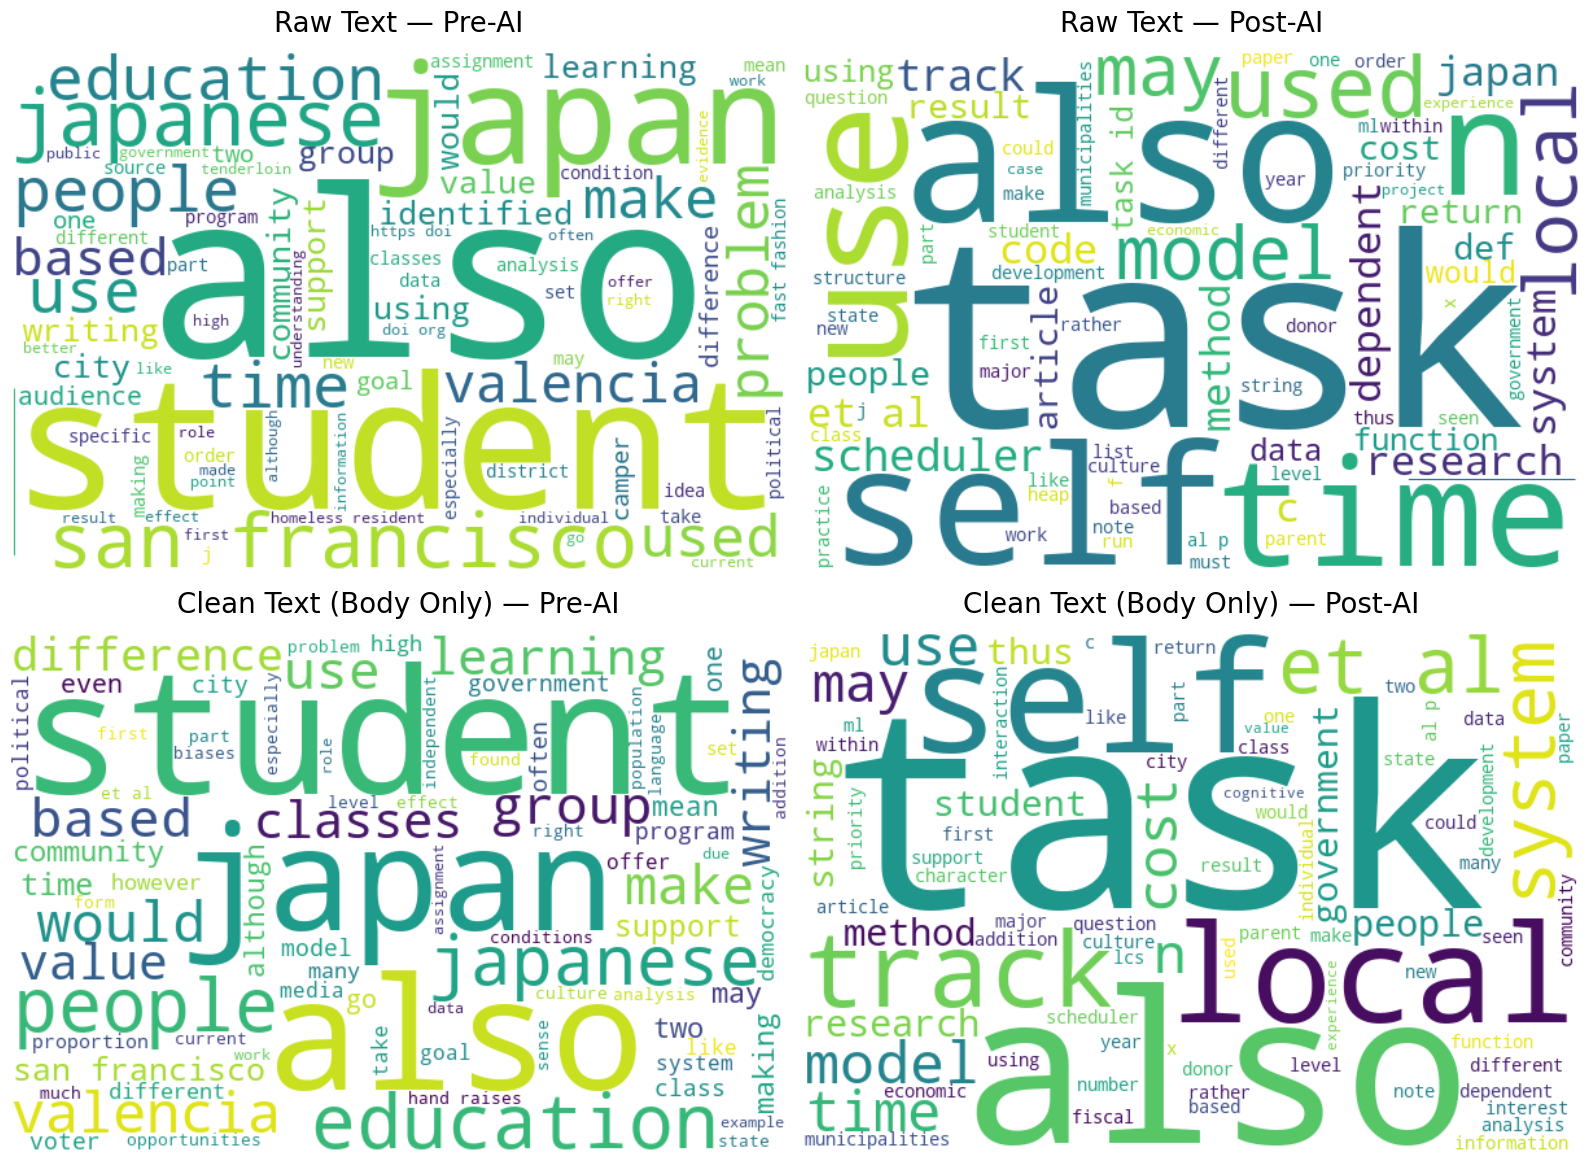

In [10]:
# Wordcloud to visualize subject matter and content

# Generic English stopwords 
stop_words = set(stopwords.words('english'))
# Remove APA/structural noise 
stop_words.update(['figure', 'table'])  

fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # increased height for padding

text_sources = [
    ('text_raw_norm', 'Raw Text'),
    ('text_clean_norm', 'Clean Text (Body Only)')
]

labels_to_plot = [0, 1]
label_names = ['Pre-AI', 'Post-AI']

for row, (text_col, text_label) in enumerate(text_sources):
    for col, (label, label_name) in enumerate(zip(labels_to_plot, label_names)):
        ax = axes[row, col]
        
        combined_text = ' '.join(
            df_processed[df_processed['label'] == label][text_col].astype(str).tolist()
        )
        
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='viridis',
            max_words=80,
            relative_scaling=0.5,
            min_font_size=10,
            stopwords=stop_words
        ).generate(combined_text)
        
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{text_label} — {label_name}', fontsize=20, pad=15)

plt.tight_layout()
plt.show()

The histograms below show how the engineered features differ across classes. All show significant overlap, suggesting that no single feature is sufficient to reliably distinguish classes—classification will require combinations of multiple features. 

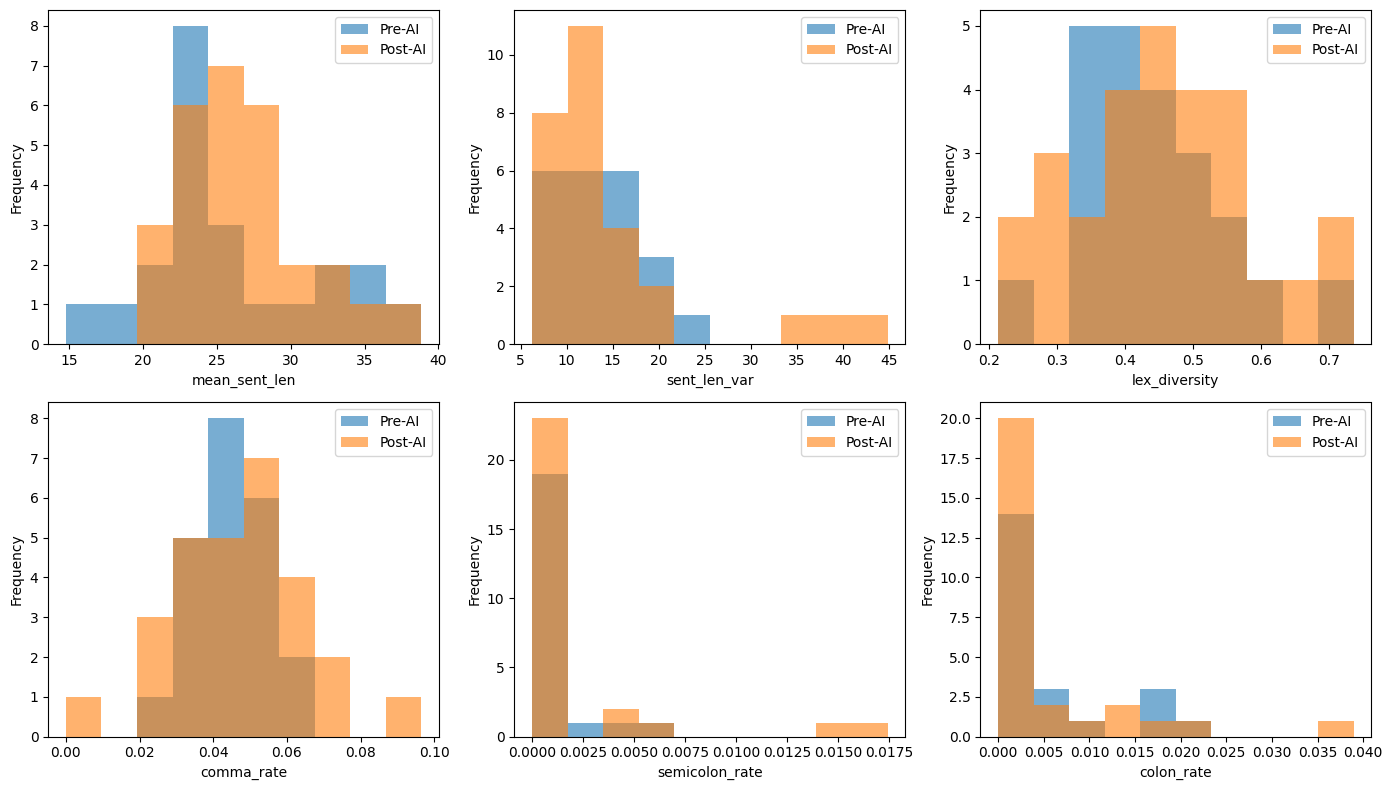

In [11]:
# Stylometric feature distributions

# Stylometric feature distributions

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features_to_plot = ['mean_sent_len', 'sent_len_var', 'lex_diversity', 'comma_rate', 'semicolon_rate', 'colon_rate']

for ax, feat in zip(axes.flat, features_to_plot):
    # Get the range of the feature across both groups
    min_val = X_clean_df[feat].min()
    max_val = X_clean_df[feat].max()
    bins = np.linspace(min_val, max_val, 11)  # 10 bins
    
    ax.hist(X_clean_df[X_clean_df['label']==0][feat], bins=bins, alpha=0.6, label='Pre-AI')
    ax.hist(X_clean_df[X_clean_df['label']==1][feat], bins=bins, alpha=0.6, label='Post-AI')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

The heatmaps below show pair-wise feature correlations within each class separately. Most feature pairs show weak correlations (close to 0), which is favorable for classification models: highly correlated features would be redundant and inflate importance estimates. Comparing the heatmaps across classes also reveals whether correlation structures differ between Pre-AI and Post-AI writing. 

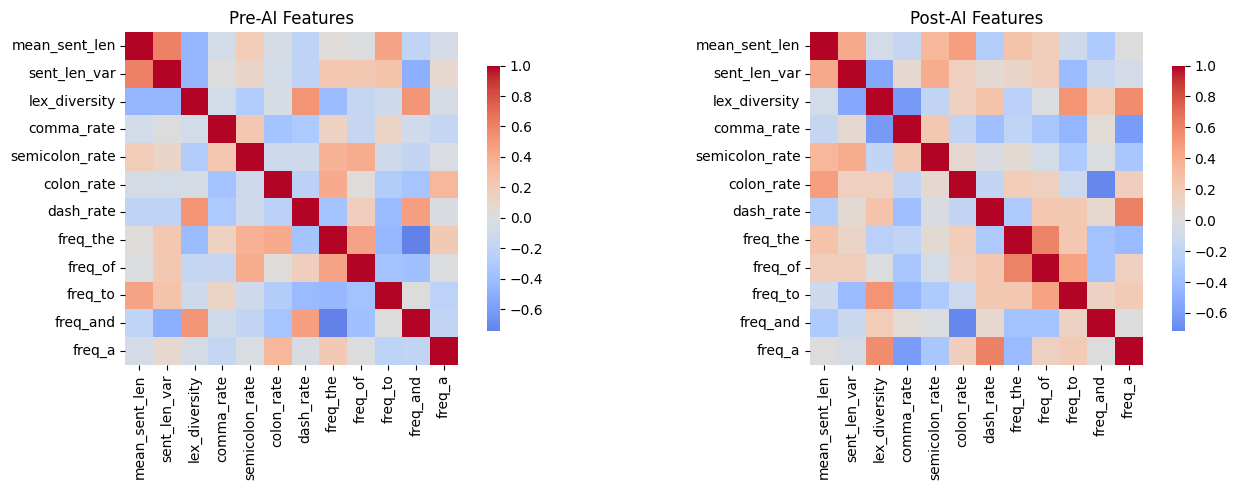

In [12]:
# Heatmap of feature correlations by label 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, label in enumerate([0, 1]):
    subset = X_clean_df[X_clean_df['label']==label].drop(['name', 'course_code', 'label'], axis=1)
    corr = subset.corr()
    sns.heatmap(corr, ax=axes[idx], cmap='coolwarm', center=0, square=True, 
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f"{'Pre-AI' if label==0 else 'Post-AI'} Features")

plt.tight_layout()
plt.show()

While lexical diversity within individual documents is useful, I was also curious whether my writing has regressed toward common English words—a documented characteristic of LLM output. Since LLMs are probabilistic models trained on large text corpora, they tend to favor high-frequency words and avoid uncommon vocabulary.

To test this, I computed a corpus-relative diversity metric using the top 1000 most common words from the NLTK Brown Corpus as a baseline (I chose this corpus for easy access via NLTK). The Brown Corpus is a 1 million-word collection of texts from diverse genres and serves as a standard linguistic reference for American English. I then measured what proportion of words in each document fell within this established frequency list.

Based on the violin plots, my pre-AI assignments tend to use fewer common words overall, whereas my post-AI work shows greater variability: some use over 70% common vocabulary, while others maintain more specialized vocabulary.


In [13]:
# Exploratory: Corpus-relative diversity (regression to common words)

# Download NLTK Brown Corpus if not available and extract top 1000 most common words
try:
    nltk.data.find('corpora/brown')
except LookupError:
    nltk.download('brown')

from nltk.corpus import brown
word_freq = nltk.FreqDist(w.lower() for w in brown.words() if w.isalpha())
TOP_1000_WORDS = set(word for word, freq in word_freq.most_common(1000))

print(f"Loaded top 1000 words from Brown Corpus. Total corpus words: {len(word_freq)}")

def compute_corpus_relative_diversity(df_tokens):
    """
    Compute corpus-relative metrics (exploratory, not main features).
    
    Measures: % of words that fall in top 1000 most common English words (from Brown Corpus).
    High % = regressing to mean (AI-like behavior)
    Low % = maintaining quirky/unique vocabulary
    """
    results = []
    
    for idx, row in df_tokens.iterrows():
        token_dict = row["token_data"]
        words = token_dict["words"]
        
        words_lower = [w.lower() for w in words]
        total_words = len(words_lower)
        
        common_count = sum(1 for w in words_lower if w in TOP_1000_WORDS)
        common_ratio = common_count / total_words if total_words > 0 else 0
        
        results.append({
            "name": row["name"],
            "label": row["label"],
            "common_word_ratio": common_ratio,
            "unique_words_count": len(set(words_lower))
        })
    
    return pd.DataFrame(results)

# Compute corpus-relative metrics for exploration
corpus_rel_raw = compute_corpus_relative_diversity(df_tokens_raw)
corpus_rel_clean = compute_corpus_relative_diversity(df_tokens_clean)

print("Corpus-relative diversity computed.")


Loaded top 1000 words from Brown Corpus. Total corpus words: 40234
Corpus-relative diversity computed.


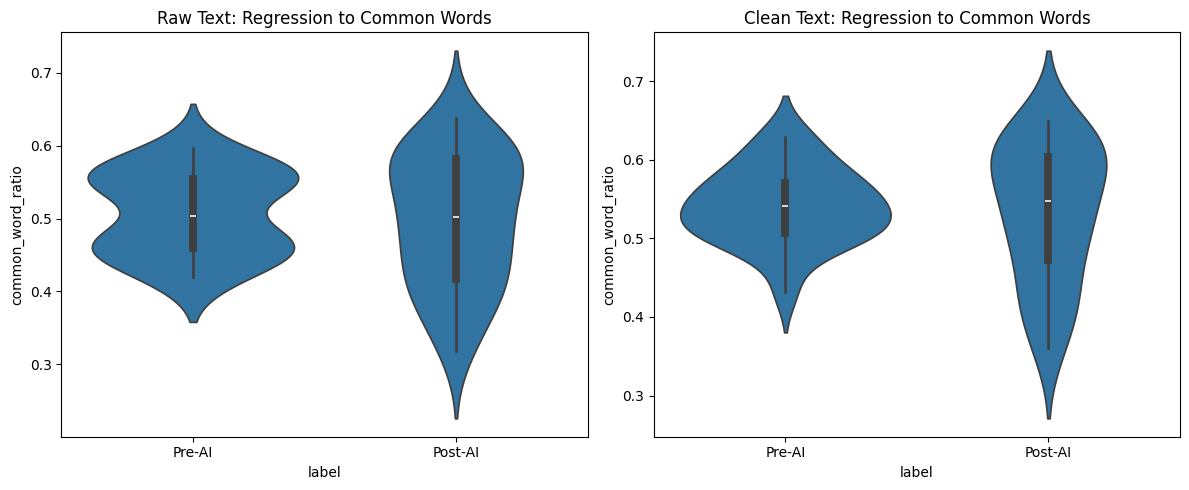

In [14]:
# Common word ratio distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=corpus_rel_raw, x='label', y='common_word_ratio', ax=axes[0])
axes[0].set_title('Raw Text: Regression to Common Words')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Pre-AI', 'Post-AI'])

sns.violinplot(data=corpus_rel_clean, x='label', y='common_word_ratio', ax=axes[1])
axes[1].set_title('Clean Text: Regression to Common Words')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Pre-AI', 'Post-AI'])

plt.tight_layout()
plt.show()

## Analysis

### Classification Approach

To determine whether my writing has shifted stylistically post-Fall 2024, I trained three interpretable and complementary classification models on the engineered features: 

* **Naive Bayes**: makes strong independence assumptions and performs well when features don't heavily correlate. This is a reasonable assumption given the weak correlations observed in the heatmaps. 
* **Logistic Regression**: Provides interpretable coefficients that show which features most strongly predict the label. 
* **Linear SVM**: Finds a maximum-margin separator and is robust to outliers. This makes it useful for validating whether the classes are truly separable in feature space.

### Training Strategy: Raw vs. Clean Text

A key question underlying this analysis is whether the cleaning pipeline removes content important to the classification task. To answer this, I trained each model twice: once on features computed from **raw text** and once on features computed from **clean text** (body only, without cover sheets, references, etc.). 

If models trained on raw text perform substantially better, it suggests that stylistic signal comes from removed sections—potentially indicating leakage from metadata rather than prose style. If performance is similar or clean text performs nearly as well, it validates that the cleaned text contains sufficient stylistic information and supports the cleaning strategy.

### Evaluation: Stratified 5-Fold Cross-Validation

I held out 5 documents as a final test set, then used stratified 5-fold cross-validation on the remaining 45 documents to evaluate each model. This approach:
- Preserves an independent hold-out set for final performance reporting
- Maximizes training data use on the 45-document training set (training on 36 docs per fold, testing on 9)
- Reduces variance in performance estimates by averaging across folds
- Maintains class balance within each fold

For each fold, I report accuracy, precision, recall, and F1-score on the held-out test set, then average these metrics across all 5 folds to produce cross-validation estimates. After selecting the best model, I train a final model on all 45 training documents and evaluate it on the independent 5-document hold-out set.

In [15]:
# Hold out 5 documents for final testing, use remaining 45 for 5-fold CV training

# Feature columns 
feature_cols = [c for c in X_raw_df.columns if c not in ["name", "course_code", "label"]]

# Prepare data for splitting
X_raw_full = X_raw_df[feature_cols].values
X_clean_full = X_clean_df[feature_cols].values
y_full = X_raw_df["label"].values
doc_names = X_raw_df["name"].values
doc_labels = X_raw_df["label"].values

# Hold out 5 documents (stratified by label)
train_idx, test_idx = train_test_split(
    np.arange(len(X_raw_df)), test_size=5, stratify=y_full, random_state=42
)

X_raw_train = X_raw_full[train_idx]
X_clean_train = X_clean_full[train_idx]
y_train = y_full[train_idx]

X_raw_test = X_raw_full[test_idx]
X_clean_test = X_clean_full[test_idx]
y_test = y_full[test_idx]

# Display held-out test set
holdout_docs = doc_names[test_idx]
holdout_labels = doc_labels[test_idx]
print("Held-out test set (5 documents):")
for i, (name, label) in enumerate(zip(holdout_docs, holdout_labels)):
    print(f"  {i+1}. {name} (Label: {label})")

print(f"\nTraining set: {len(X_raw_train)} documents")
print(f"  Pre-AI (0): {(y_train == 0).sum()}")
print(f"  Post-AI (1): {(y_train == 1).sum()}")

# Create stratified 5-fold CV splitter for the training set
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Held-out test set (5 documents):
  1. LBA: Multimodal Persuasion [final] (Label: 0)
  2. LBA [final] (Label: 1)
  3. Reflection on Track Options [final] (Label: 1)
  4. Scheduler [final] (Label: 1)
  5. EA50 problem Solving Part 2 [final] (Label: 0)

Training set: 45 documents
  Pre-AI (0): 20
  Post-AI (1): 25


## Model Selection 

I chose three complementary models to assess the difference between my pre- vs post-AI writing. Using the same models on both raw- and clean-text feature sets allows me to verify whether cleaning removes stylistic signal, ensuring that any patterns detected reflect style rather than superficial formatting differences.

### Naive Bayes (Multinomial)
Naive Bayes assumes conditional independence between features. It estimates the posterior probability of each label given the features as: 

$$
P(y \mid \mathbf{x}) \propto P(y) \prod_{j=1}^{d} P(x_j \mid y)
$$

where $x_j$ is the $j^\text{th}$ feature. Classification is performed using the maximum a posteriori (MAP) rule, which selects the label with the highest posterior probability:

$$
\hat{y} = \arg\max_y P(y \mid \mathbf{x})
$$

This model is lightweight, interpretable, and provides a baseline to compare against more flexible methods. However, it assumes that punctuation counts, function word frequencies, and sentence-level metrics independently contribute to the probability of pre/post AI writing, which does not hold in the case of real writing.

### Logistic Regression  
Logistic regression models the probability of the positive class using a **sigmoid function**:

$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}} 
$$

It learns the weights $\mathbf{w}$ and bias $b$ by minimizing the cross-entropy loss:

$$
\mathcal{L} = -\sum_{i=1}^{n} \left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

Coefficients indicate the direction and strength of each feature’s contribution. For example, higher mean sentence length or certain function word frequencies may increase the probability of a text being pre- or post-AI. Logistic regression is interpretable, fast, and well-suited for small datasets like mine.

### Linear Support Vector Machine (SVM)  
Linear SVM seeks the **maximum-margin hyperplane** that separates the two classes in feature space. It solves the optimization problem:

$$
\min_{\mathbf{w},b} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n}\max(0, 1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b))
$$

where the first term, $\frac{1}{2}\|\mathbf{w}\|^2$, maximizes the margin between classes, and the second term penalizes misclassifications. The parameter $C$ is a regularization parameter that controls the trade-off between a wide margin (more generalization) and correctly classifying every point (potential overfitting).  

Essentially, SVM tries to find a decision boundary that is as far as possible in feature space from all points while allowing some violations if the classes are not perfectly separable. Each support vector directly influences the position of the hyperplane, which makes SVM robust to outliers that are far from the boundary.  

In the context of my stylometry features, each document is represented in a 12-dimensional feature space. SVM assesses whether these features collectively form a linearly separable boundary between pre- and post-AI writing. Unlike Naive Bayes, SVM does not assume independence between features, and unlike logistic regression, it focuses on maximizing the margin rather than fitting probabilities directly.  

Notably, in the logistic regression and SVM, I use the StandardScaler to standardize each feature to mean 0 and variance 1 because they rely on regularization and distance, and scaling keep the coefficients comparable. 

In [16]:
# Model initialization for stylometric feature vectors

models = {
    "NaiveBayes": MultinomialNB(),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, random_state=42))
    ])
}

## Training

To train the models, I used stratified 5‑fold cross‑validation for each on both the raw‑feature and clean‑feature datasets after holding out 5 entries for final out-of-sample testing. In each fold, the model is trained on 80% of the data and evaluated on the held‑out 20%. The table reports the averages of evaluations metrics (accuracy, precision, recall, and F1) across the 5 folds along with std. 

Logistic Regression and Linear SVM achieved comparable performance across both raw and clean text (57.8% accuracy on raw, 55.6% on clean), substantially outperforming Naive Bayes (48.9% on raw, 46.7% on clean). While the performance drop from raw to clean text shows that metadata (formatting, boilerplate) does contribute signal, the 55.6% clean-text accuracy—better than chance—confirms that measurable stylistic differences exist between pre- and post-AI writing. Naive Bayes, despite lower accuracy, demonstrated high recall (84% on both raw and clean), suggesting sensitivity to class imbalance. Notably, LogReg and SVM's consistency across both raw and clean datasets indicates that the stylistic signal we detect is subtle but genuine, validating the necessity of preprocessing to isolate true stylistic markers independent of structural elements. 

Although Logistic Regression and Linear SVM achieved nearly identical cross-validation performance, I selected **Logistic Regression trained on clean text** as the final model for three key reasons:

1. Interpretability & Feature Attribution
Logistic Regression provides direct coefficient estimates that quantify each feature's contribution to the prediction, which offers straightfoward interpretation of which stylistic markers drive the classification (e.g., does punctuation usage matter more than sentence length?). SVM's decision boundary on the other hand is less transparent although more mathematically elegant. 

2. Probabilistic Output & Confidence Calibration  
Logistic Regression produces calibrated probability estimates (via the sigmoid function) that reflect genuine uncertainty, which are concrete measures of how well the model has learned real patterns. Conversely, the distances from the hyperplane produced by the SVM decision boundary do not directly correspond to class probability. 

3. Extensibility to Temporal Analysis 
The next phase of this project involves training a time-series regression model to examine how stylistic features change continuously over time. Logistic Regression's linear structure and coefficient interpretability make it a precursor to temporal models (e.g., ordinal logistic regression or generalized additive models that track style drift). 

In summary, Logistic Regression balances performance parity with SVM while providing the interpretability and extensibility needed for further stylometric analysis.

In [17]:
# Train each model on training data (45 docs) using 5-fold cross-validation

# Sanity check: training and test labels should match
assert len(y_train) == 45, f"Expected 45 training docs, got {len(y_train)}"
assert len(y_test) == 5, f"Expected 5 test docs, got {len(y_test)}"

def run_cv(models_dict, X, y, cv):
    """Run stratified CV and return mean and std metrics per model."""
    results = []

    for model_name, model in models_dict.items():
        fold_acc = []
        fold_prec = []
        fold_rec = []
        fold_f1 = []

        for fold_idx, (fold_train_idx, fold_test_idx) in enumerate(cv.split(X, y)):
            X_fold_train, X_fold_test = X[fold_train_idx], X[fold_test_idx]
            y_fold_train, y_fold_test = y[fold_train_idx], y[fold_test_idx]

            # Fit and predict
            model.fit(X_fold_train, y_fold_train)
            y_fold_pred = model.predict(X_fold_test)

            # Store metrics
            fold_acc.append(accuracy_score(y_fold_test, y_fold_pred))
            fold_prec.append(precision_score(y_fold_test, y_fold_pred, zero_division=0))
            fold_rec.append(recall_score(y_fold_test, y_fold_pred, zero_division=0))
            fold_f1.append(f1_score(y_fold_test, y_fold_pred, zero_division=0))

        results.append({
            "model": model_name,
            "accuracy_mean": np.mean(fold_acc),
            "accuracy_std": np.std(fold_acc),
            "precision_mean": np.mean(fold_prec),
            "precision_std": np.std(fold_prec),
            "recall_mean": np.mean(fold_rec),
            "recall_std": np.std(fold_rec),
            "f1_mean": np.mean(fold_f1),
            "f1_std": np.std(fold_f1),
        })

    return pd.DataFrame(results)

# Run 5-fold CV on the training set (45 docs) for both raw and clean
print("Running 5-fold CV on training set (45 docs)...\n")

raw_results = run_cv(models, X_raw_train, y_train, skf)
raw_results["dataset"] = "raw"

clean_results = run_cv(models, X_clean_train, y_train, skf)
clean_results["dataset"] = "clean"

cv_results = pd.concat([raw_results, clean_results], ignore_index=True)

# Display results
cv_results = cv_results[[
    "dataset", "model",
    "accuracy_mean", "accuracy_std",
    "precision_mean", "precision_std",
    "recall_mean", "recall_std",
    "f1_mean", "f1_std",
]]

print("Cross-Validation Results (averaged across 5 folds):")
cv_results


Running 5-fold CV on training set (45 docs)...

Cross-Validation Results (averaged across 5 folds):


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,raw,NaiveBayes,0.488889,0.133333,0.514286,0.090685,0.84,0.233238,0.634632,0.136747
1,raw,LogisticRegression,0.577778,0.129577,0.630000,0.124900,0.60,0.126491,0.611313,0.119145
2,raw,LinearSVM,0.577778,0.083148,0.636667,0.083267,0.60,0.126491,0.607879,0.081618
3,clean,NaiveBayes,0.466667,0.108866,0.504762,0.062209,0.84,0.195959,0.628571,0.104978
4,clean,LogisticRegression,0.555556,0.099381,0.586667,0.074833,0.64,0.149666,0.608889,0.108788
5,clean,LinearSVM,0.555556,0.099381,0.603333,0.096839,0.60,0.126491,0.596768,0.097738


## Predictions 

To assess performance on the held-out test data, I trained the selected Logistic Regression model on the clean data. The model achieved perfect 5/5 accuracy on the holdout set, but with important caveats:

- **Perfect accuracy (5/5 correct)**, but all predictions made with moderate confidence (53-69%)
- **No high-confidence predictions** (none ≥80%), suggesting the stylistic signal is real but subtle
- **Average confidence: 61.1%** — above chance (~50%) but well below "obviously different" (≥80%)

Given the small dataset (50 documents total), the feature set had to be reduced to the most informative 12 stylometric features. This dimensionality reduction likely prevented overfitting but also limited the model’s ability to assign extremely high probabilities.  

Taken together, these results indicate that measurable stylistic drift exists, but the changes are gradual rather than dramatic. The moderate confidence levels suggest that the model learned genuine patterns in sentence length, punctuation, lexical diversity, and function word use, rather than memorizing idiosyncrasies or overfitting to noise.  

These findings support the notion that my writing has shifted subtly over time. However, it only points to general drift, not alignment with AI writing specifically. To properly test this hypothesis, as a future extension I will train a time series regression model to understand how my style chanved over time, and whether the direction of change aligns with AI writing. 

In [18]:
# Retrain Logistic Regression on full training data (clean text)

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit on full training set
final_model.fit(X_clean_train, y_train)
print(f"\n✓ Model trained on {len(X_clean_train)} documents")

# Generate predictions on held-out test set
y_pred_final = final_model.predict(X_clean_test)
y_pred_proba = final_model.predict_proba(X_clean_test)

# Compute performance metrics on hold-out set
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, zero_division=0)
final_recall = recall_score(y_test, y_pred_final, zero_division=0)
final_f1 = f1_score(y_test, y_pred_final, zero_division=0)

print("OUT-OF-SAMPLE PERFORMANCE (5-Document Hold-Out Test Set)")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")



✓ Model trained on 45 documents
OUT-OF-SAMPLE PERFORMANCE (5-Document Hold-Out Test Set)
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


Average Prediction Confidence: 61.1%
Min Confidence: 52.9%
Max Confidence: 69.3%
High-Confidence Predictions (≥80%): 0/5



/var/folders/d6/qn8gssfj7355xpg0c9755v400000gn/T/ipykernel_11699/3877203602.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', fontsize=9)


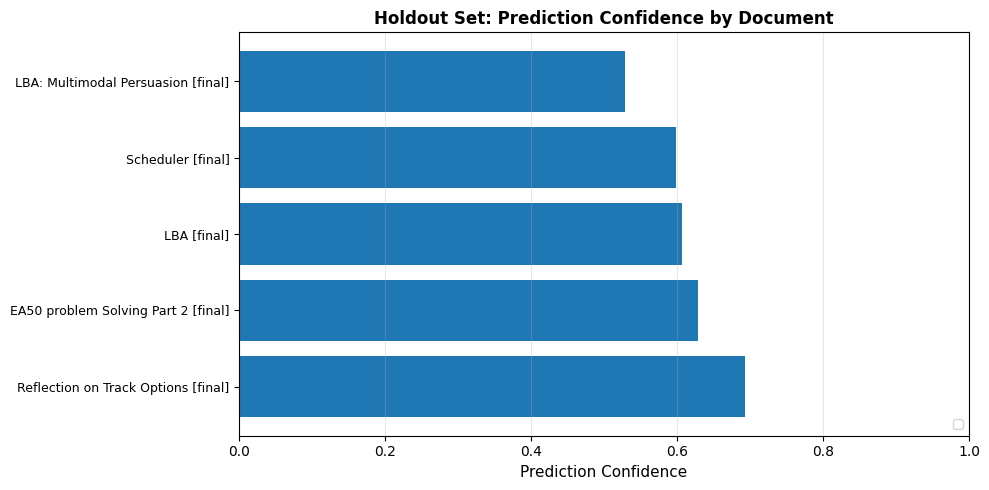

In [19]:
# Visualize Prediction Confidence

# Create dataframe with document names, true labels, predictions, and confidence scores
pred_df = pd.DataFrame({
    'Document': [X_clean_df.iloc[j]["name"] for j in test_idx],
    'True_Label': ['Pre-AI' if label == 0 else 'Post-AI' for label in y_test],
    'Predicted_Label': ['Pre-AI' if label == 0 else 'Post-AI' for label in y_pred_final],
    'Confidence_Pre': y_pred_proba[:, 0],
    'Confidence_Post': y_pred_proba[:, 1]
})

# Add a column for the confidence in the predicted class
pred_df['Prediction_Confidence'] = [
    pred_df.iloc[i]['Confidence_Pre'] if pred_df.iloc[i]['Predicted_Label'] == 'Pre-AI' 
    else pred_df.iloc[i]['Confidence_Post']
    for i in range(len(pred_df))
]

# Sort by confidence descending
pred_df_sorted = pred_df.sort_values('Prediction_Confidence', ascending=False)

# Compute statistics
avg_confidence = pred_df['Prediction_Confidence'].mean()
min_confidence = pred_df['Prediction_Confidence'].min()
max_confidence = pred_df['Prediction_Confidence'].max()
high_confidence_count = (pred_df['Prediction_Confidence'] >= 0.8).sum()

print(f"Average Prediction Confidence: {avg_confidence:.1%}")
print(f"Min Confidence: {min_confidence:.1%}")
print(f"Max Confidence: {max_confidence:.1%}")
print(f"High-Confidence Predictions (≥80%): {high_confidence_count}/{len(pred_df)}")
print()

# Visualize confidence
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(pred_df_sorted)), pred_df_sorted['Prediction_Confidence'])

ax.set_yticks(range(len(pred_df_sorted)))
ax.set_yticklabels(pred_df_sorted['Document'], fontsize=9)
ax.set_xlabel('Prediction Confidence', fontsize=11)
ax.set_title('Holdout Set: Prediction Confidence by Document', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

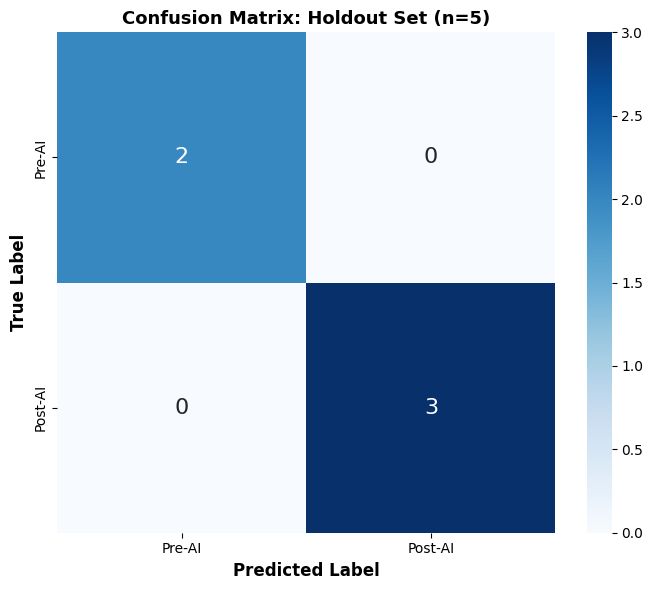

True Negatives (Pre-AI correctly identified): 2
False Positives (Pre-AI misclassified as Post-AI): 0
False Negatives (Post-AI misclassified as Pre-AI): 0
True Positives (Post-AI correctly identified): 3


In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Pre-AI', 'Post-AI'],
            yticklabels=['Pre-AI', 'Post-AI'],
            ax=ax, annot_kws={'size': 16})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: Holdout Set (n=5)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"True Negatives (Pre-AI correctly identified): {cm[0, 0]}")
print(f"False Positives (Pre-AI misclassified as Post-AI): {cm[0, 1]}")
print(f"False Negatives (Post-AI misclassified as Pre-AI): {cm[1, 0]}")
print(f"True Positives (Post-AI correctly identified): {cm[1, 1]}")

## Discussion 



The coefficient visualization for the final model trained above shows which stylistic features most strongly predict post-AI writing:

**Strongest Predictors of Pre-AI Writing (negative = pre-AI):**
- **High "of" frequency** (coef: -1.21): Pre-AI writing uses more prepositional phrases, suggesting denser relational language or more complex clause structures. This could reflect conscious, deliberate prose construction or simply differ subject matter.
- **High "and" frequency** (coef: -0.37): Pre-AI work uses more conjunctions, indicating greater coordination of ideas. This *could* mark less polished writing, but without further analysis it's unclear whether this is stylistic or content-driven.

**Strongest Predictors of Post-AI Writing (positive = post-AI):**
- **Higher lexical diversity** (coef: 0.549): Post-AI writing reuses fewer words proportionally, suggesting either broader vocabulary or less thematic focus. The cause is ambiguous and could reflect course-dependent writing expectations rather than AI influence.
- **Higher "the" frequency** (coef: 0.564): Increased definite article use *might* reflect more formal, reference-heavy tone, but could equally result from subject matter shifts across courses.
- **Higher dash rate** (coef: 0.408): Post-AI writing uses more em-dashes. While em-dash overuse is considered the hallmark of LLM outputs, it could also reflect personal stylistic evolution or formal writing norms in later courses. And, for the record, I have always used em-dashes. 
- **Higher semicolon and comma rates** (coef: 0.32, 0.30): Increased punctuation density suggests either more complex sentence structures or deliberate stylistic choices.

### Interpretation: Competing Hypotheses

The model distinguishes the two periods, but the cause remains open to interpretation:

**Hypothesis 1: AI-influenced style**  
I may have unconsciously adopted stylistic patterns from exposure to AI text (em-dashes, formal punctuation, lexical variation). However, this is speculative without direct comparison to AI writing from the same period.

**Hypothesis 2: Course/context shift**  
Post-AI courses (Cores and Concentrations; more technical) may have implicit stylistic expectations (formality, precision) that differ from pre-AI courses (Conerstones). The coefficient changes could reflect subject matter rather than AI influence.

**Hypothesis 3: Maturation or self-editing**  
Increased lexical diversity and punctuation density could reflect deliberate writing improvement over time, independent of AI exposure.

### Limitations

- **Lack of baseline comparison**: Without analyzing actual AI-generated text from Fall 2024, I cannot determine whether my post-AI style *resembles* or *diverges from* known AI markers.
- **Correlation ≠ causation**: High "the" frequency predicts post-AI writing, but doesn't indicate *why*. Course-specific vocabulary norms could explain this entirely.
- **Confounded variables**: Time, course type, and subject matter all changed between pre- and post-AI periods. Isolating stylistic drift from content drift is difficult.
- **Feature interactions**: The model treats features independently, but punctuation and sentence length likely correlate, leading to inflated weights.

### Concrete Findings

- **Measurable stylistic differences exist** between pre-Fall 2024 and post-Fall 2024 writing (55.6% CV accuracy, better than chance). 
- **The changes are subtle**, with moderate confidence levels (53-69%) suggesting genuine patterns, not memorization. 
- **Stylistic signal persists after removing metadata**, supporting the data cleaning approach. 

### Next Steps: Temporal & Comparative Analysis

To strengthen claims, future work should:
- Train **time-series regression** to examine whether coefficients change *monotonically* over time or spike at specific courses. 
- Collect **AI-generated baselines** (GPT outputs from the same courses/prompts) and compare trajectory directly. 
- Perform **within-course (or college) analysis** to isolate subject matter effects from temporal effects. 
- Conduct **error analysis** to understand which documents the model misclassifies and why. 


Top Features Predicting Post-AI Writing (positive = post-AI):
       feature  coefficient  abs_coefficient
       freq_of    -1.214245         1.214245
      freq_the     0.564280         0.564280
 lex_diversity     0.549487         0.549487
     dash_rate     0.408621         0.408621
      freq_and    -0.369938         0.369938
semicolon_rate     0.319174         0.319174
    comma_rate     0.297270         0.297270
    colon_rate    -0.231457         0.231457
 mean_sent_len     0.195113         0.195113
        freq_a     0.186362         0.186362


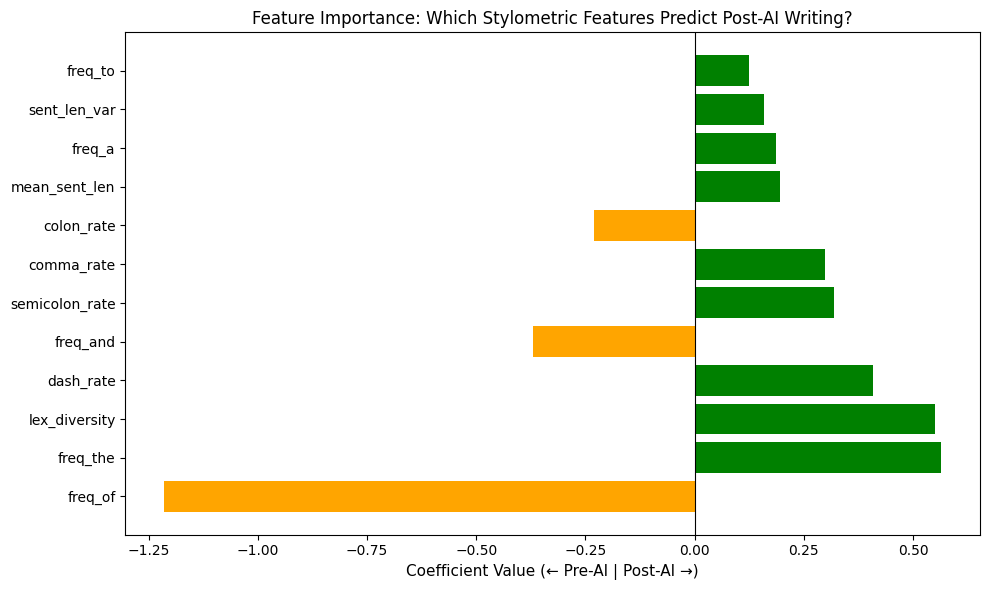

In [21]:
# Visualize coefficients

coefficients = final_model.named_steps['clf'].coef_[0]
feature_names = feature_cols 

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("\nTop Features Predicting Post-AI Writing (positive = post-AI):")
print(coef_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_features = coef_df.head(12)
colors = ['green' if c > 0 else 'orange' for c in top_features['coefficient']]
ax.barh(range(len(top_features)), top_features['coefficient'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Coefficient Value (← Pre-AI | Post-AI →)', fontsize=11)
ax.set_title('Feature Importance: Which Stylometric Features Predict Post-AI Writing?', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

## Summary

### Pipeline Overview

This analysis trains a binary classifier to determine whether my writing style has shifted between pre-Fall 2024 (before widespread AI adoption) and post-Fall 2024 (after). The pipeline:

1. **Clean text:** Remove metadata, cover sheets, references, AI statements
2. **Tokenize:** spaCy sentence and word segmentation
3. **Engineer features:** 12 stylometric metrics (sentence length, punctuation rates, function word frequencies, lexical diversity)
4. **Train/test split:** 45 documents for 5-fold cross-validation, 5 held-out for final evaluation
5. **Model selection:** Logistic Regression (on clean text) outperformed Naive Bayes and SVM on interpretability and extensibility
6. **Results:** 55.6% CV accuracy on clean text; perfect holdout accuracy with moderate confidence (53–69%)


![Pipeline Diagram](pipeline_diagram.png)

### Key Findings

- **Stylistic drift does exist:** 55.6% accuracy substantially exceeds 50% chance baseline
- **Signal persists after cleaning:** Performance drop from raw (57.8%) to clean (55.6%) validates that metadata contributes minimally; true stylistic differences remain
- **Changes are subtle:** Moderate prediction confidence (avg 61.1%) suggests genuine patterns
- **Top distinguishing features:** Post-AI writing shows higher lexical diversity, dash rate, and "the" frequency; pre-AI shows higher "of" and "and" frequency

### Limitations

The cleaned text contains measurable stylistic differences, but not necessarily cause by AI exposure:
- No baseline comparison to actual AI-generated text
- Course/subject matter confounded with time (cannot isolate style from content)
- Binary cutoff ignores gradual adoption and within-course variation
- Small dataset (50 total documents) limits generalization

### Next Steps

To confirm AI influence, future work should:
- Collect LLM outputs from same assignment prompts and train classifier on **my writing vs. AI writing** (instead of pre/post)
- Perform temporal regression to track style changes continuously rather than binary split
- Add syntactic/readability features and isolate course effects via within-course analysis

## References 

- Session 5 PCW: https://forum.minerva.edu/app/courses/3804/sections/13026/classes/99436 
- Wikipedia, (n.d.-a). Signs of AI writing https://en.wikipedia.org/wiki/Wikipedia:Signs_of_AI_writing
- Wikipedia, (n.d.-b). Most common words in English https://en.wikipedia.org/wiki/Most_common_words_in_English#:~:text=The%20researchers%20published%20their%20analysis,in%20the%20Oxford%20English%20Corpus.
- Wikipedia, (n.d.-c). Support vector machine https://en.wikipedia.org/wiki/Support_vector_machine
- Hastewire, 2025-a. How Machine Learning Identifies Writing Style: Techniques Revealed https://hastewire.com/blog/how-machine-learning-identifies-writing-style-techniques-revealed
- Hastewire, 2025-b. How AI Detectors Interpret Sentence Structure: Key Insights https://hastewire.com/blog/how-ai-detectors-interpret-sentence-structure-key-insights


## AI Statement

I used GitHub Copilot's autocomplete feature to assist with code, and Copilot Agent mode to refactor code. 

I also used ChatGPT as a brainstorming partner and to guide modeling decisions, such as how I might use my limited data, in what order I should preprocess my documents, and what features might be the best suited to my research question. Full conversation link here: https://chatgpt.com/share/699b4396-8f24-8011-a00b-ddb50f688270 

I also passed all of my markdown cells into Grammarly for sentence-level editing. 